In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.mixture import GaussianMixture

Cluster means:
[[5.57721357 2.04303224]
 [1.4619995  0.24599977]
 [4.30594388 1.34787855]]

First 5 probability predictions:
[[2.99590401e-19 9.99999994e-01 6.03023352e-09]
 [2.99590401e-19 9.99999994e-01 6.03023352e-09]
 [1.34120339e-19 9.99999997e-01 3.31592798e-09]
 [9.43553867e-19 9.99999986e-01 1.43420261e-08]
 [2.99590401e-19 9.99999994e-01 6.03023352e-09]]


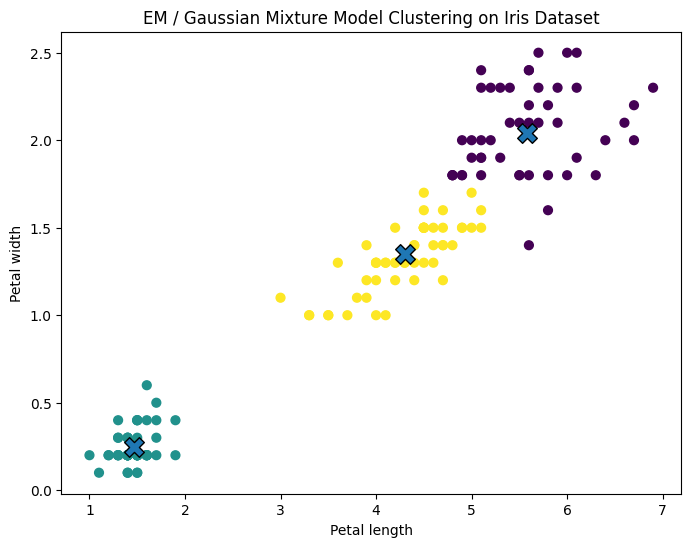

In [5]:
# Load real dataset
iris = load_iris()

# Use only 2 features so we can visualize in 2D
# petal length and petal width
X = iris.data[:, [2, 3]]

# Train EM algorithm through Gaussian Mixture Model
gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42
)

gmm.fit(X)

# Predict cluster labels
labels = gmm.predict(X)

# Predict probabilities/responsibilities
probs = gmm.predict_proba(X)

print("Cluster means:")
print(gmm.means_)

print("\nFirst 5 probability predictions:")
print(probs[:5])

# Plot data colored by predicted cluster
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=40)

# Plot learned Gaussian centers
plt.scatter(
    gmm.means_[:, 0],
    gmm.means_[:, 1],
    marker="X",
    s=200,
    edgecolors="black"
)

plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.title("EM / Gaussian Mixture Model Clustering on Iris Dataset")
plt.show()